# Simple-linear Regression 
- Single dependent and Independent feature. 
- In Ml we use LinearRegression model in very rare case. 

# Import libraries

In [3]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
salary_df = pd.read_csv(r'D:\AI & ML\Machine_Learning_19\Dataset\salary_data.csv')
salary_df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


# EDA 

In [5]:
salary_df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
salary_df.tail(5)

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [7]:
salary_df.shape

(30, 2)

In [8]:
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
salary_df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [10]:
salary_df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

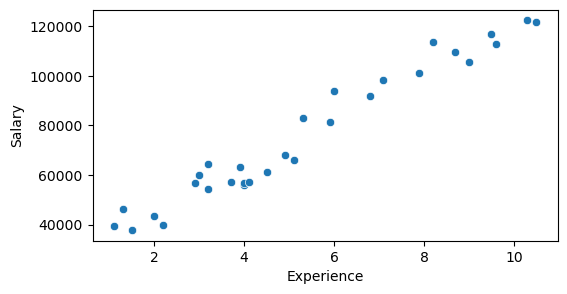

In [11]:
plt.figure(figsize=(6,3))
sns.scatterplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')

plt.xlabel('Experience')
plt.ylabel('Salary')

plt.show()

Text(0, 0.5, 'Salary')

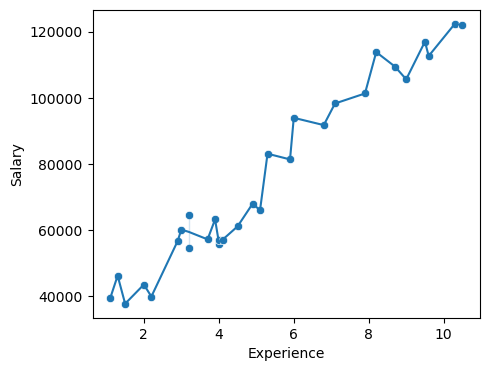

In [12]:
plt.figure(figsize=(5,4))
sns.scatterplot(data= salary_df,
                x = 'YearsExperience',
                y = 'Salary')
sns.lineplot(data = salary_df,
             x = 'YearsExperience',
            y = 'Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')



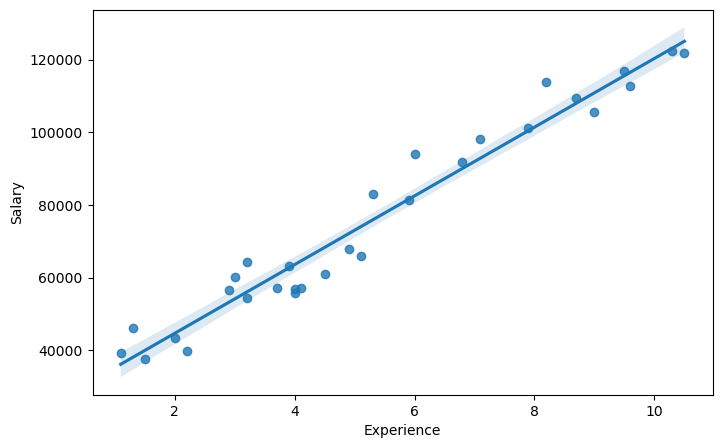

In [13]:
plt.figure(figsize=(8,5))

sns.regplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')

plt.xlabel('Experience')
plt.ylabel('Salary')

plt.show()

### Threw this graph we can easily understand which type of model we can use.

# Feature Selection

In [14]:
# 1st we divide into 2 parts 1st in independent feature 2nd is Dependent feature.
X = salary_df[['YearsExperience']]   # Here we have to convert 1D to 2D in simple linearRegression.
Y = salary_df['Salary']

# Split data into train and test

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3)  # test_size=0.3 means 30% of data store in test part except data store in training part.

In [16]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(21, 1) (9, 1)
(21,) (9,)


# Modal Building


In [17]:
from sklearn.linear_model import LinearRegression
Linear_model = LinearRegression()
Linear_model.fit(X_train,Y_train)    # We use fit for to explain in wich data you have to take and train.

LinearRegression()

#

In [18]:
X_test

,YearsExperience
9,3.7
29,10.5
0,1.1
2,1.5
11,4.0
19,6.0
23,8.2
22,7.9
3,2.0


In [29]:
prediction =  Linear_model.predict(X_test)

In [30]:
prediction

array([ 60839.32307897, 123287.75417471,  36961.98177766,  40635.41890094,
        63594.40092143,  81961.58653782, 102165.49071585,  99410.41287339,
        45227.21530504])

In [23]:
Y_test

9      57189.0
29    121872.0
0      39343.0
2      37731.0
11     55794.0
19     93940.0
23    113812.0
22    101302.0
3      43525.0
Name: Salary, dtype: float64

# Modal performance evaluation

In [24]:
# Training accuracy
print(Linear_model.score(X_train,Y_train))

0.9539777790847902


In [25]:
print(Linear_model.score(X_test,Y_test))

0.9585981949654043


In [31]:
from sklearn.metrics import r2_score
print(r2_score(Y_test,prediction)*100)
print(f'Modal accuracy {r2_score(Y_test,prediction)*100}')


95.85981949654044
Modal accuracy 95.85981949654044


In [27]:
import pickle

In [33]:
with open(r'Linear_Train_model_sala.pkl','wb') as file:
    pickle.dump(Linear_model,file)